<a href="https://colab.research.google.com/github/Sanathcharan/Data-Science-ExcelR/blob/main/SLR_%26_MLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('experience_vs_salary.csv')
df

,Experience (Years),Salary ($)
0,1,30000
1,2,35000
2,3,40000
3,4,45000
4,5,50000
5,6,60000
6,7,65000
7,8,75000
8,9,85000
9,10,95000


In [ ]:
df.size


20

In [ ]:
df.shape

(10, 2)

In [ ]:
df.isnull().sum()

,0
Experience (Years),0
Salary ($),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
x=df.drop(columns='Salary ($)')
y=df['Salary ($)']

In [ ]:
x

,Experience (Years)
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [ ]:
y

,Salary ($)
0,30000
1,35000
2,40000
3,45000
4,50000
5,60000
6,65000
7,75000
8,85000
9,95000


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [ ]:
x_train

,Experience (Years)
6,7
2,3
4,5
1,2
5,6
3,4
9,10
0,1


In [ ]:
x_test

,Experience (Years)
7,8
8,9


In [ ]:
print(x_train.shape)
print(x_test.shape)


(8, 1)
(2, 1)


In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
# y=bo+b1x

In [ ]:
print(lr.coef_) #b1


[7058.82352941]


In [ ]:
print(lr.intercept_) #bo

18970.58823529412


In [ ]:
# 18970.588+7058.8*x

In [ ]:
x_test

,Experience (Years)
7,8
8,9


In [ ]:
lr.predict(x_test)

array([75441.17647059, 82500.        ])

In [ ]:
pred=lr.predict(x_test)
pred

array([75441.17647059, 82500.        ])

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
r2_score(y_test,pred)

0.8711072664359861

In [ ]:
# model training
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train) #model
pred=lr.predict(x_test) #prediction
pred
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
r2_score(y_test,pred) #evaluation

0.8711072664359861

In [ ]:
# RMSE of Trained mode
root_mean_squared_error(y_test,pred)

1795.0817081961331

# **Multi linear regression**

In [ ]:
df=pd.read_csv('Cars.csv')
df

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [ ]:
df.min()

,0
HP,49.000000
MPG,12.101263
VOL,50.000000
SP,99.564907
WT,15.712859


In [ ]:
df.shape

(81, 5)

In [ ]:
df.size

405

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


In [ ]:
df.isnull().sum()

,0
HP,0
MPG,0
VOL,0
SP,0
WT,0


In [ ]:
df.duplicated().sum()

np.int64(0)

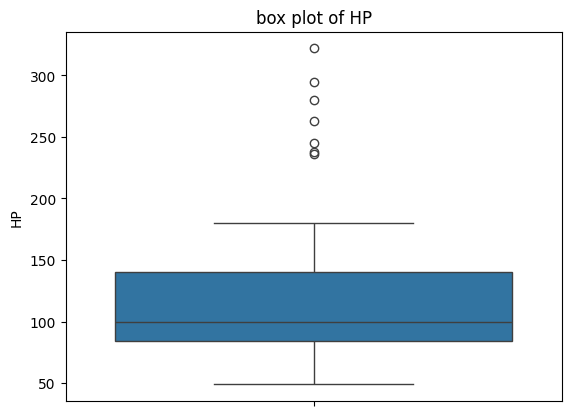

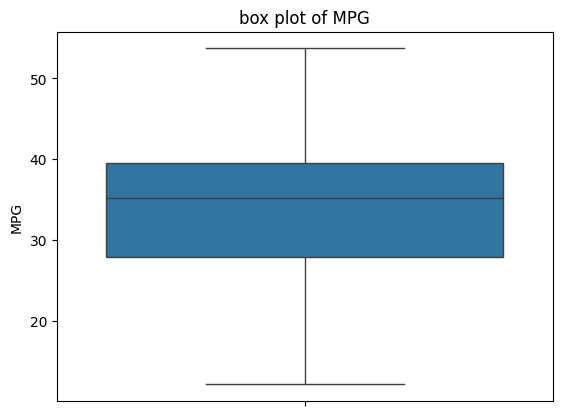

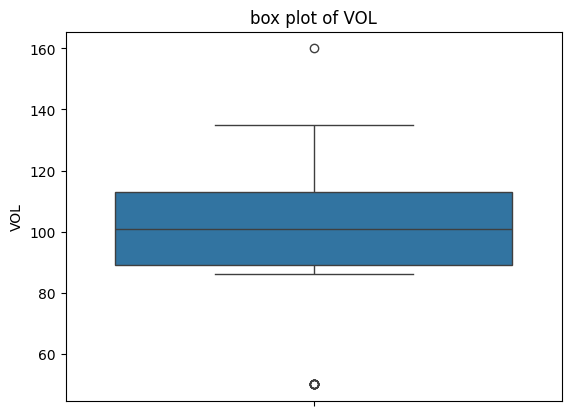

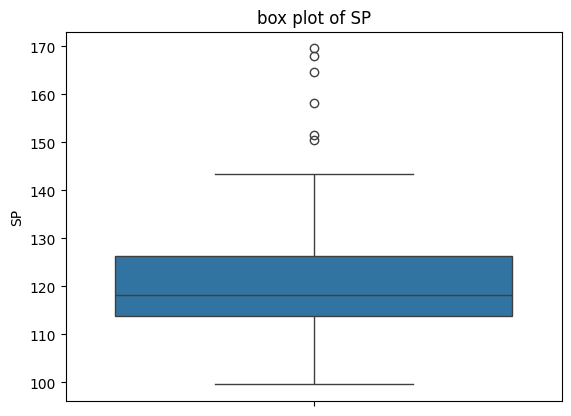

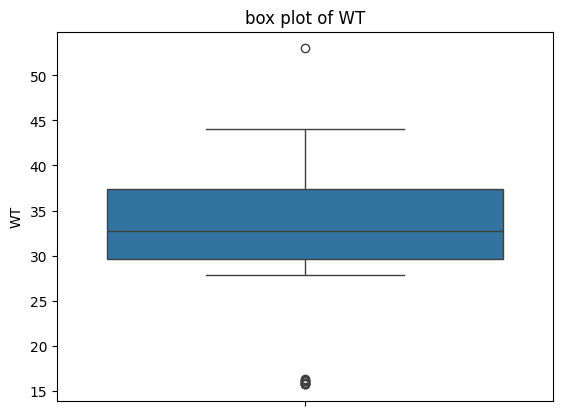

In [ ]:
for col in df.select_dtypes(exclude='object').columns:
    sns.boxplot(y=df[col])
    plt.title(f'box plot of {col}')
    plt.show()

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  upper=q3+1.5*iqr
  lower=q1-1.5*iqr
  df[i]=df[i].clip(lower,upper)

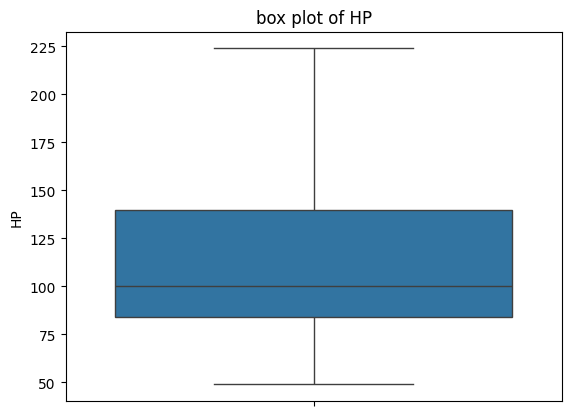

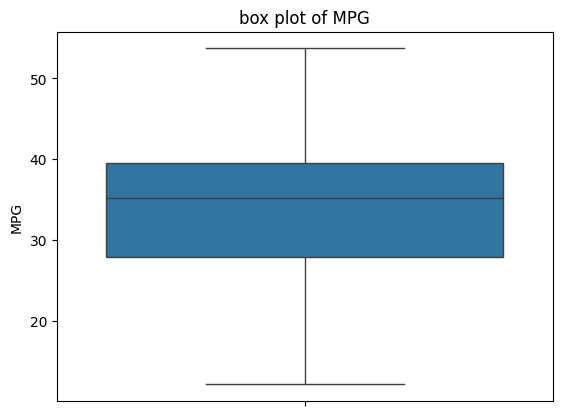

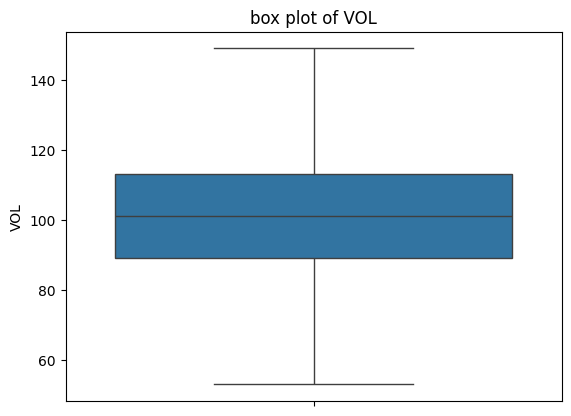

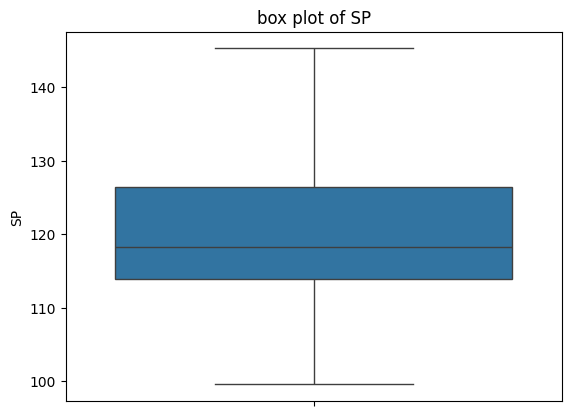

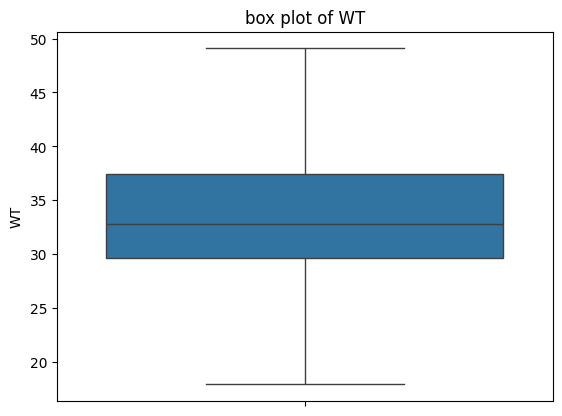

In [ ]:
for col in df.select_dtypes(exclude='object').columns:
    sns.boxplot(y=df[col])
    plt.title(f'box plot of {col}')
    plt.show()

<Axes: >

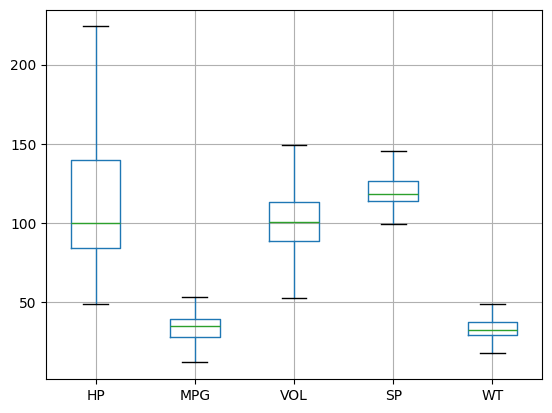

In [ ]:
df.boxplot()

In [ ]:
df

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,224,36.900000,53,145.267062,17.890634
77,224,19.197888,115,145.267062,37.923113
78,224,34.000000,53,145.267062,17.890634
79,224,19.833733,119,145.267062,39.423099


<Axes: >

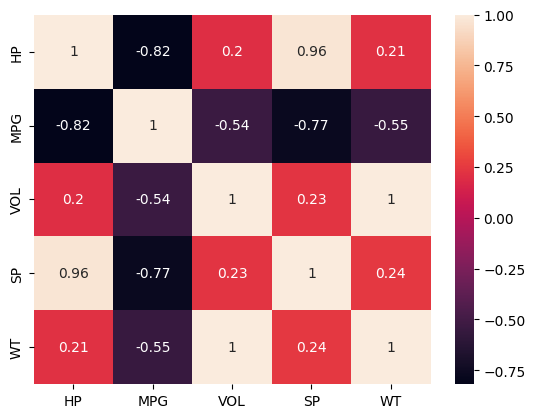

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
feat=df[['HP','VOL','SP','WT']]

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data=pd.DataFrame()
vif_data['feature']=feat.columns
vif_data['VIF']=[variance_inflation_factor(feat.values,i) for i in range(feat.shape[1])]
print(vif_data.sort_values(by='VIF',ascending=False))


  feature           VIF
3      WT  12655.607213
1     VOL  12275.559937
2      SP     44.233571
0      HP     12.532669


In [ ]:
# predict a model to predict the mfg of a variable
x=df.drop(columns='MPG')
y=df['MPG']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=55)

In [ ]:
# model training
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train) #model
pred=lr.predict(x_test) #prediction
pred
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
r2_score(y_test,pred) #evaluation
print("r2_score:",r2_score(y_test,pred))
print("mean_absolute_error:",mean_absolute_error(y_test,pred))
print("mean_squared_error:",mean_squared_error(y_test,pred))
print("root_mean_squared_error:",root_mean_squared_error(y_test,pred))

r2_score: 0.799271297004017
mean_absolute_error: 2.633822494693276
mean_squared_error: 14.339594977680154
root_mean_squared_error: 3.7867657674696695


In [ ]:
lr.coef_

array([-0.24273121, -0.17176509,  0.43427302, -0.0045847 ])

In [ ]:
lr.intercept_

np.float64(26.69613508138211)

# **Example program**

In [ ]:
df=pd.read_csv('Advertising.csv')
df

,ID,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [ ]:
df.shape

(200, 5)

In [ ]:
df.size

1000

In [ ]:
df.isnull().sum()

,0
ID,0
TV,0
radio,0
newspaper,0
sales,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         200 non-null    int64  
 1   TV         200 non-null    float64
 2   radio      200 non-null    float64
 3   newspaper  200 non-null    float64
 4   sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


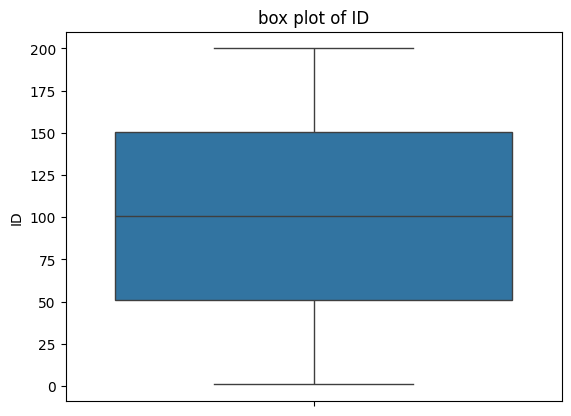

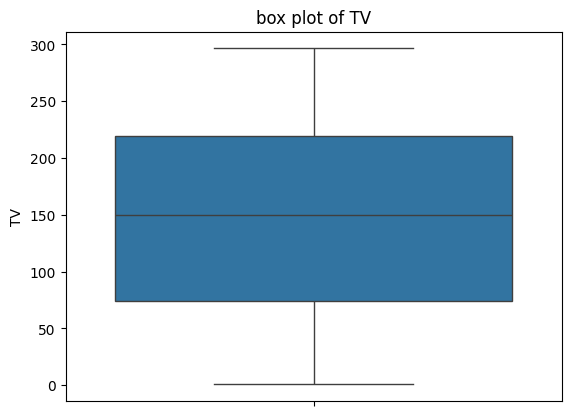

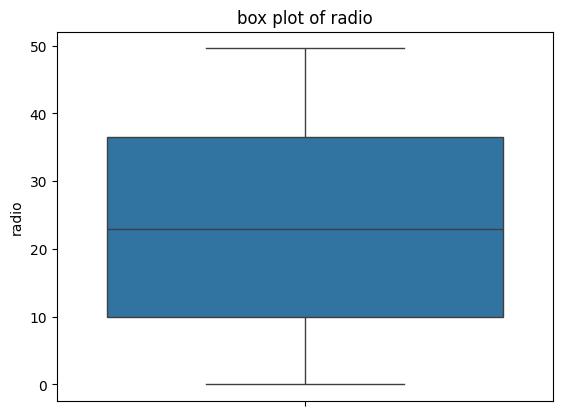

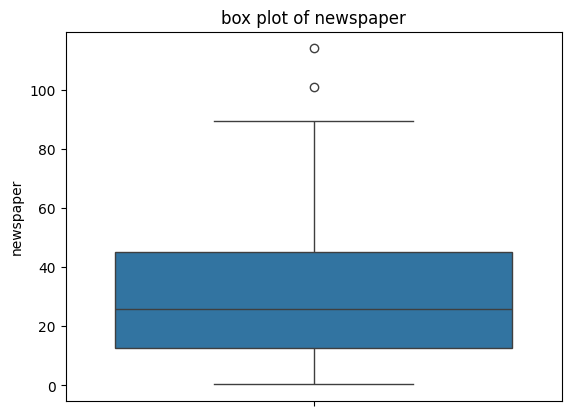

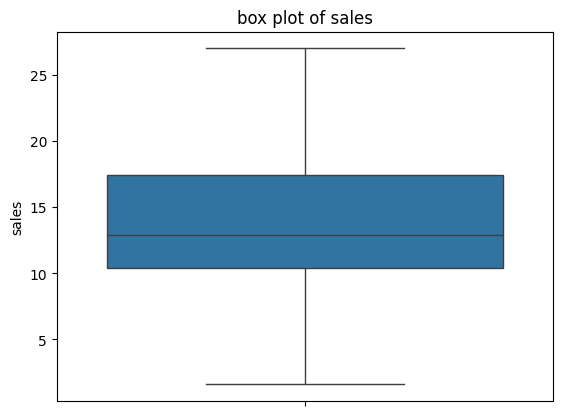

In [ ]:
# checking oultiers
for col in df.select_dtypes(exclude='object').columns:
    sns.boxplot(y=df[col])
    plt.title(f'box plot of {col}')
    plt.show()

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  upper=q3+1.5*iqr
  lower=q1-1.5*iqr
  df[i]=df[i].clip(lower,upper)

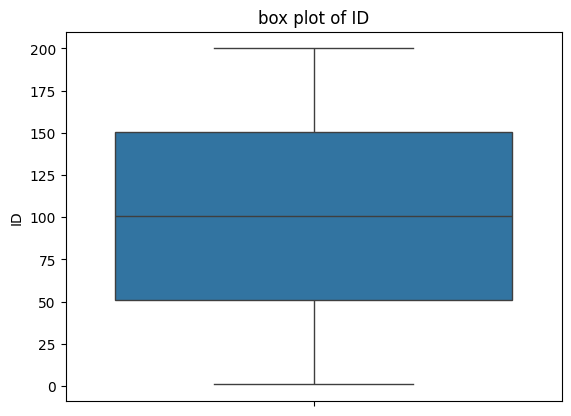

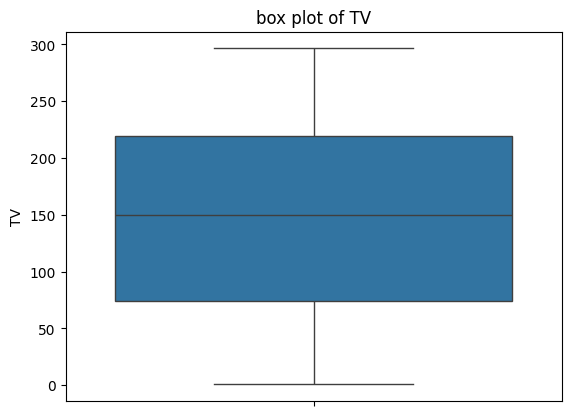

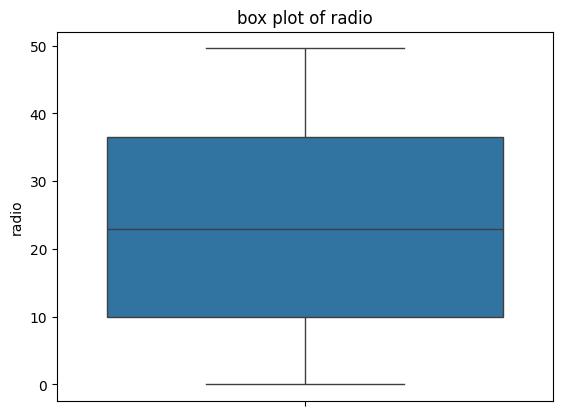

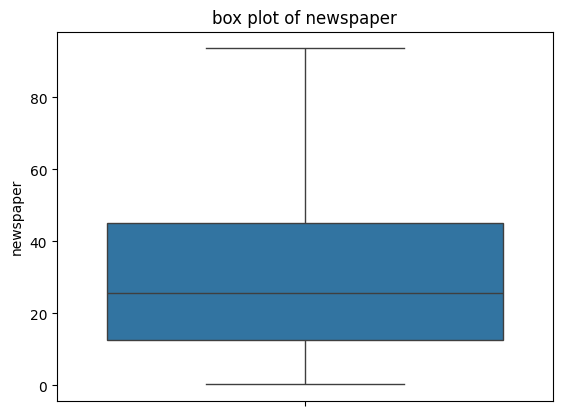

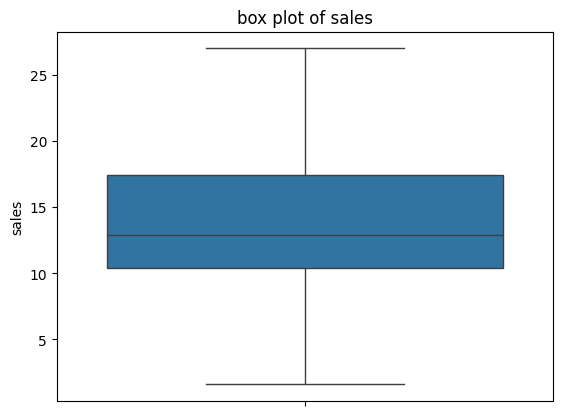

In [ ]:
for col in df.select_dtypes(exclude='object').columns:
    sns.boxplot(y=df[col])
    plt.title(f'box plot of {col}')
    plt.show()

<Axes: >

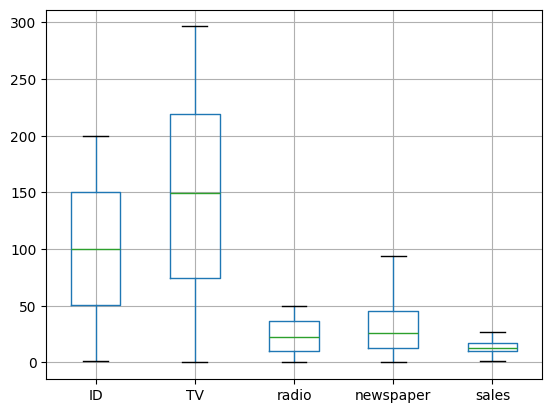

In [ ]:
df.boxplot()

In [ ]:
df

,ID,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


<Axes: >

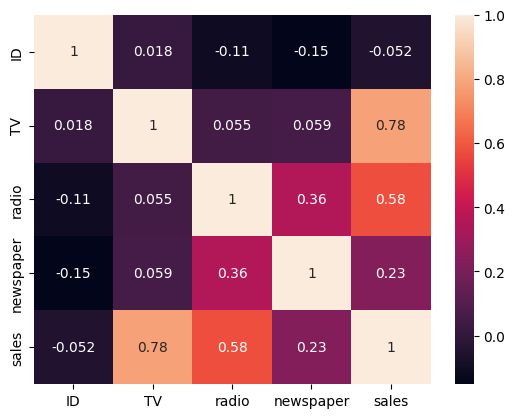

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
feat=df[['ID','TV','radio','newspaper']]

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data=pd.DataFrame()
vif_data['feature']=feat.columns
vif_data['VIF']=[variance_inflation_factor(feat.values,i) for i in range(feat.shape[1])]
print(vif_data.sort_values(by='VIF',ascending=False))

     feature       VIF
2      radio  3.463771
3  newspaper  3.152631
1         TV  3.112851
0         ID  2.612937


In [ ]:
x=df.drop(columns='sales')
y=df['sales']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=55)

In [ ]:
# model training
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train) #model
pred=lr.predict(x_test) #prediction
pred
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
r2_score(y_test,pred) #evaluation
print("r2_score:",r2_score(y_test,pred))
print("mean_absolute_error:",mean_absolute_error(y_test,pred))
print("mean_squared_error:",mean_squared_error(y_test,pred))
print("root_mean_squared_error:",root_mean_squared_error(y_test,pred))

r2_score: 0.8979263595124268
mean_absolute_error: 1.2380761576843426
mean_squared_error: 2.570007568355105
root_mean_squared_error: 1.6031243146915042


In [ ]:
lr.coef_

array([ 0.00151273,  0.04452112,  0.19604714, -0.00580315])

In [ ]:
lr.intercept_

np.float64(3.023036339066742)